# ITI5201 Machine Learning

### 1. Model Complexity and Model Selection

 Question 1, KNN Regressor

1.1 Implement a KNN regressor using the scikit-learn conventations

In [1]:
#Importing the library that will be used for this question

from scipy.spatial import KDTree
from sklearn.base import BaseEstimator
import numpy as np

# Implementing KNN Regressor

#Base estimator is initialized so the class implement the utility function from sklearn
class KnnRegression(BaseEstimator):
    #Initializing the object
    def __init__(self, k):
        self.k = k
    #Initializing the fit function to make the model
    def fit(self, x, y):
        self.y_train_ = y
        self.x_train_kdtree_ = KDTree(x)
        return self
    #Initializing the predict to predict the neighbor and classify the data
    def predict(self, x):
        #Using kdtree library to do nearest neighbor search, the _ is used to catch unneeded value
        _, neighbours = self.x_train_kdtree_.query(x, k=self.k)
        #Making sure the result from above have the same shape as x
        neighbours = neighbours.reshape(len(x), self.k)
        #To predict the label according to the training data then calculates how far each datapoint to the target
        neighbour_labels = self.y_train_[neighbours]
        m = np.mean(neighbour_labels, axis=1, keepdims=False)
        return m
    

1.2 To test your implementation, load the datasets diabetes and california housing through the functions load diabetes and fetch california housing, both of which are available in the module sklearn.datasets.

In [2]:
#Importing the library that will be used for this question

from sklearn.datasets import load_diabetes
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

#Loading both dataset
diabetes = load_diabetes()
housing = fetch_california_housing()

#Splitting both dataset to each variables
diabet_x_train, diabet_x_test, diabet_y_train, diabet_y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.6, random_state=42)
house_x_train, house_x_test, house_y_train, house_y_test = train_test_split(housing.data, housing.target, test_size=0.6, random_state=42)

#Making the KNN regression for both dataset
knn_diabet = KnnRegression(4).fit(diabet_x_train, diabet_y_train)
knn_housing = KnnRegression(4).fit(house_x_train, house_y_train)

#Predicting the diabetes dataset for train and test
diabet_predict_train = knn_diabet.predict(diabet_x_train)
diabet_predict_test = knn_diabet.predict(diabet_x_test)

#Predicting the housing dataset for train and test
housing_predict_train = knn_housing.predict(house_x_train)
housing_predict_test = knn_housing.predict(house_x_test)

Calculating the error rate

In [3]:
#Importing the library that will be used for this question
from sklearn.metrics import mean_squared_error as mse

#Making a function to calculate the relative squared error
def rse(y, y_hat):
    return sum((y-y_hat)**2)

#Printing the calculation for mean squared error and relative squared error for diabetes KNN prediction
print("Diabetes MSE for train, test ", round(mse(diabet_y_train, diabet_predict_train), 5), round(mse(diabet_y_test, diabet_predict_test), 5))
print("Diabetes RSE for train, test ", round(rse(diabet_y_train, diabet_predict_train), 5), round(rse(diabet_y_test, diabet_predict_test), 5))

#Printing the calculation for mean squared error and relative squared error for housing KNN prediction
print("Housing MSE for train, test ", round(mse(house_y_train, housing_predict_train), 5), round(mse(house_y_test, housing_predict_test), 5))
print("Housing RSE for train, test ", round(rse(house_y_train, housing_predict_train), 5), round(rse(house_y_test, housing_predict_test), 5))

Diabetes MSE for train, test  2795.89737 4137.69408
Diabetes RSE for train, test  492077.9375 1100626.625
Housing MSE for train, test  0.74327 1.25286
Housing RSE for train, test  6136.42332 15515.42104


### 2. L-Fold Cross Validation

2.1 Implement a L-Fold Cross Validation (CV) scheme using the scikit-learn convention for data splitters.

In [4]:
# Implementing Cross Validation

class LFold:
    #Initializing the object
    def __init__(self, reps, random_state=None):
        self.reps = reps
        self.RNG = np.random.default_rng(random_state)
    #Initializing the splits
    def get_n_splits(self):
        return self.reps

    #Making the Lfold function 
    def split(self, x, y=None, groups=None):
        #To randomize the dataset
        idx = np.arange(len(x))
        #To make sure the splitted dataset have the same number of splits
        indices = np.linspace(0, len(idx), num=self.reps + 1, dtype=int)
        #For looping to make multiple fold according to the reps
        for i in range(1, len(indices)):
            test_idx = idx[indices[i-1]:indices[i]]
            train_idx = np.setdiff1d(idx, test_idx)
            yield train_idx, test_idx

2.2 For both datasets from Question 1, use your L-fold CV implementation to systematically test the effect of the KNN parameter K by testing all options from 1 to 50 and, for each K, instead of only performing a single training/test split run your L-Fold CV. For each K compute the mean and standard deviation of the mean squared error (training and test) across the L folds and report the K for which you found the best test performance (for both datasets)

In [5]:
#Importing the library that will be used for this question
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

#Making the function to test the effect of KNN on diabetes dataset
def evaluate(x, y, max_k, cv):
    #retrieves the splits from the cross validation
    r = cv.get_n_splits()
    #Making the array for the train and test results and specify the shape of the array
    test_results = np.zeros(shape=(max_k, r))
    train_results = np.zeros(shape=(max_k, r))
    #For loop to test for each k then use cross validate to perform crossvalidate on the dataset
    for k in range(1, max_k+1):
        #Setting the k for KNN regression
        knn = KnnRegression(k)
        #Using KNN to predict the diabetes dataset and crossvalidate it 
        cv_res = cross_validate(knn, x, y, cv=cv, return_train_score=True, scoring=make_scorer(mse))
        #Storing the test and train result
        test_results[k-1, :] = cv_res['test_score']
        train_results[k-1, :] = cv_res['train_score']

    return train_results, test_results



#Setting the total reps and maximum K
reps=20
max_k=50

#Using both function on both dataset to get the train and test prediction result
train_results_diabetes, test_results_diabetes = evaluate(diabetes.data, diabetes.target, max_k=max_k, cv=LFold(reps, random_state=True))
train_results_housing, test_results_housing = evaluate(housing.data, housing.target, max_k=max_k, cv=LFold(reps, random_state=True))
    

In [6]:
#Calculating the best k for train and test, mean and std for diabetes dataset
print('Best k for train mean diabetes is:', np.argmin(np.mean(train_results_diabetes, axis=1))+1)
print('Best k for train std diabetes is:', np.argmin(np.std(train_results_diabetes, axis=1))+1)
print('Best k for test mean diabetes is:', np.argmin(np.mean(test_results_diabetes, axis=1))+1)
print('Best k for test std diabetes is:', np.argmin(np.std(test_results_diabetes, axis=1))+1)

Best k for train mean diabetes is: 1
Best k for train std diabetes is: 1
Best k for test mean diabetes is: 18
Best k for test std diabetes is: 24


In [7]:
#Calculating the best k for train and test, mean and std for housing dataset
print('Best k for train mean housing is:', np.argmin(np.mean(train_results_housing, axis=1))+1)
print('Best k for train std housing is:', np.argmin(np.std(train_results_housing, axis=1))+1)
print('Best k for test mean housing is:', np.argmin(np.mean(test_results_housing, axis=1))+1)
print('Best k for test std housing is:', np.argmin(np.std(test_results_housing, axis=1))+1)

Best k for train mean housing is: 1
Best k for train std housing is: 1
Best k for test mean housing is: 10
Best k for test std housing is: 1


2.3 For both datasets, plot the mean training and test errors against the choice of K with error bars (using the standard error of the mean).

– The effect of the parameter K. For both datasets, identify regions of overfitting and underfitting for the KNN model.
– The effect of the parameter L of the CV procedure. HINT: You might want to repeat the above process with different values for L to get an intuition of its e↵ect.

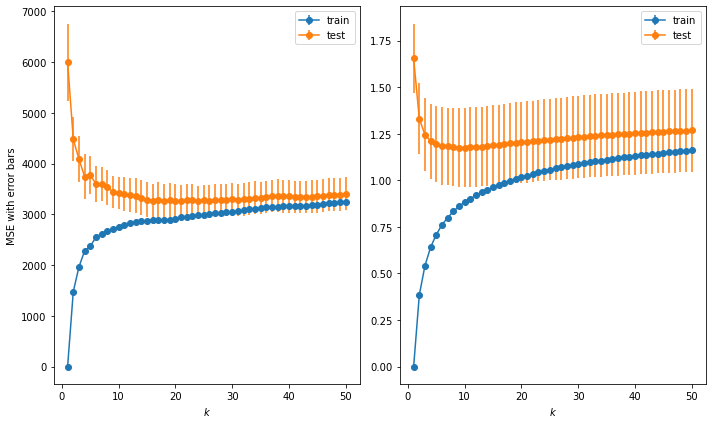

In [8]:
#Importing the library that will be used for this question
from matplotlib import pyplot as plt

#Initialize the x value from 0 until max k
ks = np.arange(1, max_k+1)
#Create 2 plot (side by side) _ is the unneeded value
_, axs = plt.subplots(1, 2, figsize=(10,6), tight_layout=True)
#Formula to compute standard error
z = (reps**0.5)/1.96
#Making graph for the train result for diabetes dataset and make the errorbar from the std
axs[0].errorbar(ks, np.mean(train_results_diabetes, axis=1), yerr=np.std(train_results_diabetes, axis=1)/z, marker='o', label='train')
#Making graph for the test result for diabetes dataset and make the errorbar from the std
axs[0].errorbar(ks, np.mean(test_results_diabetes, axis=1), yerr=np.std(test_results_diabetes, axis=1)/z, marker='o', label='test')
#To show the legend
axs[0].legend()
#To write both the x and y section
axs[0].set_xlabel('$k$')
axs[0].set_ylabel('MSE with error bars')
#Making graph for the train result for housing dataset and make the errorbar from the std
axs[1].errorbar(ks, np.mean(train_results_housing, axis=1), yerr=np.std(train_results_housing, axis=1)/z, marker='o', label='train')
#Making graph for the test result for housing dataset and make the errorbar from the std
axs[1].errorbar(ks, np.mean(test_results_housing, axis=1), yerr=np.std(test_results_housing, axis=1)/z, marker='o', label='test')
#To show the legend
axs[1].legend()
#To write the y section
axs[1].set_xlabel('$k$')
#Show the plot
plt.show()

The effect of the parameter K.

The effect of parameter K leads to bias variance trade off and sensitivity to the noise because from the graph we can see that with small K, the train data overfits while the test data underfit. Both graph only starts to converge for both data set with k at around 5-10 meaning that the number of K nearest neighbor is already sufficient enough to predict the data generally. 

Testing if the total fold is different

In [9]:
#Making the function to test the effect of L from L fold on diabetes dataset
def evaluate_cv(x, y, k, max_cv):
    #Making the array for the train and test results and specify the shape of the array
    test_results = np.zeros(shape=(max_cv-1))
    train_results = np.zeros(shape=(max_cv-1))
    knn = KnnRegression(k)
    #For loop to test the value of each L
    for c in range(2, max_cv+1):
        #Using KNN to predict the diabetes dataset and crossvalidate it 
        cv_res = cross_validate(knn, x, y, cv=LFold(c, random_state=True), return_train_score=True, scoring=make_scorer(mse))
        #Storing the test and train result
        test_results[c-2] = cv_res['test_score'].mean()
        train_results[c-2] = cv_res['train_score'].mean()

    return train_results, test_results



#Setting the total reps and K
k =5 
reps=50

#Using both function on both dataset to get the train and test prediction result
train_cv_diabetes, test_cv_diabetes = evaluate_cv(diabetes.data, diabetes.target, k=k, max_cv=reps)
train_cv_housing, test_cv_housing = evaluate_cv(housing.data, housing.target, k=k, max_cv=reps)

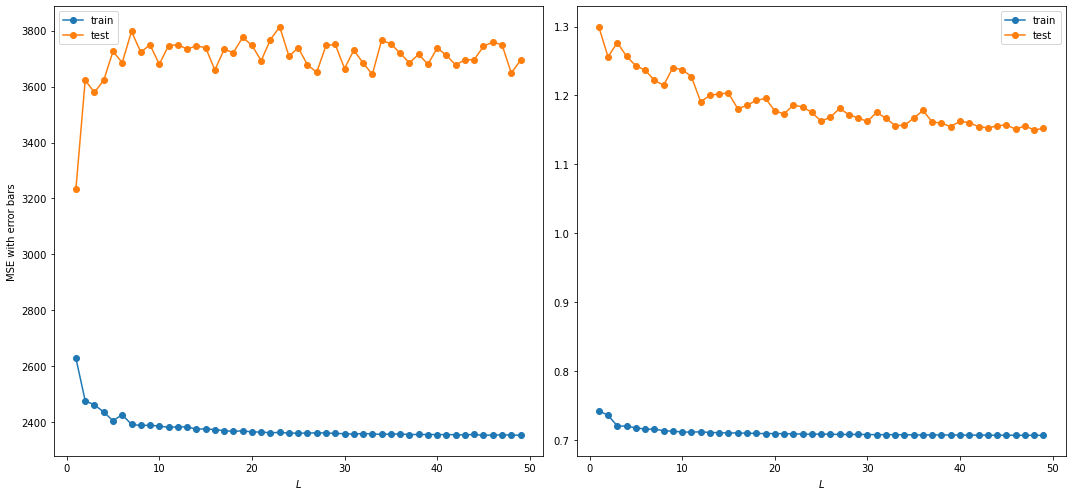

In [10]:
rs = np.arange(1, reps)
_, axs2 = plt.subplots(1, 2, figsize=(15,7), tight_layout=True)
#Making graph for the train result for diabetes dataset 
axs2[0].plot(rs, train_cv_diabetes, marker='o', label='train')
#Making graph for the test result for diabetes dataset 
axs2[0].plot(rs, test_cv_diabetes, marker='o', label='test')
#To show the legend
axs2[0].legend()
#To write both the x and y section
axs2[0].set_xlabel('$L$')
axs2[0].set_ylabel('MSE with error bars')
#Making graph for the train result for housing dataset 
axs2[1].plot(rs, train_cv_housing, marker='o', label='train')
#Making graph for the test result for housing dataset 
axs2[1].plot(rs, test_cv_housing, marker='o', label='test')
#To show the legend
axs2[1].legend()
#To write the y section
axs2[1].set_xlabel('$L$')
#Show the plot
plt.show()

The effect of L value which correspond to the K in K fold algorithm is that the values of L is at how accurate the model is. With higher value of L, there will be a lot more dataset so that the prediction model will become much more accurate and error value in the test become lower. But with diabetes having lower datacount than the housing dataset, having higher K might mean higher bias because the fold might not reflect the true distribution of the dataset because of low sample size

# Question 3 Automatic Model Selection

3.1 Implement a version of the KNN regressor that automatically chooses an appropriate value of K from a list of options by performing an internal cross-validation on the training set at fitting time.

In [11]:
#Making the Auto KNN model selection class
class AutoKNNregressor(BaseEstimator):
    def __init__(self, ks = range(1,21), l=5):
        self.ks = ks
        self.l = l
    #Making the fit function to get the test result from the KNN regression    
    def fit(self, x, y):
        #Doing the test result 
        _, test_results = evaluate(x, y, max_k=max(self.ks), cv=LFold(self.l, random_state=13))
        #To save the best K
        self.best_k = np.argmin(np.mean(test_results,axis=1)) + 1
        #To return the model with the best k that we found before and fit it
        self.knn_model = KnnRegression(self.best_k).fit(x,y)
        return self
    #To predict the y_predict using the best K
    def predict(self,x):
        return self.knn_model.predict(x)

3.2 For both datasets from the previous questions, test your KNN regressor with internal CV by using either an outer single train/test-split or, ideally, with an outer cross-validation (resulting in a so-called nested cross-validation scheme).

In [12]:
#Making the nested loop
def Nestcv(x,y):
    #Making the outer and inner fold
    outer = LFold(reps=5, random_state=13)
    inner = LFold(reps=5, random_state=13)
    #Initializing the array for the k and test_scores
    optimal_ks = np.zeros(outer.get_n_splits(), dtype=int)
    test_scores = np.zeros(outer.get_n_splits())
    #Running the knn cross validation with inner split to get the best k
    knn_cv = AutoKNNregressor(ks=list(range(1,21)), l=inner.get_n_splits())

    #Using the KNN regressor with internal cv to predict the dataset
    for i, (train, test) in enumerate(outer.split(list(range(len(x))))):
        #Initialize array
        x_train, y_train = x[train], y[train]
        x_test, y_test = x[test], y[test]
        #Fit the model
        cv_model = knn_cv.fit(x_train, y_train)
        #Taking the best k
        optimal_ks[i] = cv_model.best_k
        #Taking the error code for the best k
        test_scores[i] = mse(y_test, cv_model.predict(x_test))

    return optimal_ks, test_scores

In [13]:
#Using the diabetes dataset to KNN regressor
diabetes_cv_results = Nestcv(diabetes.data, diabetes.target)

print('The optimal k for diabetes is :', np.mean(diabetes_cv_results[0]))
print('The error score for diabetes dataset is :', np.mean(diabetes_cv_results[1]))

The optimal k for diabetes is : 18.4
The error score for diabetes dataset is : 3198.0038297407123


In [14]:
#Using the housing dataset to KNN regressor
house_cv_results = Nestcv(housing.data, housing.target)

print('Optimal K for housing:', np.mean(house_cv_results[0]))
print('The error score for diabetes dataset is:', np.mean(house_cv_results[1]))

Optimal K for housing: 9.6
The error score for diabetes dataset is: 1.2197714073248664


Best K for diabetes and housing mean from the question 2 = 18, 10 while best K from the outer and inner cross validation for diabetes and housing mean =  18.4, 9.6. We can see that the difference for the K by testing the K one by one and using inner cross validation is not that different, therefore the inner cross validation was able to successfully predict the best K. 

Factors that affect how successful internal cross-validation is selecting the best K depends on

1. Training Data size, more data means the more reliable the cross-validation will be able to estimate the model performance therefore it will be able to get the best K easier. With small dataset, some folds maybe unable to represent the whole data distribution

2. How many fold. The number of fold will impact the bias variance trade-off. Too little fold will led to higher bias while higher fold will lead to higher variance.

3. Consistency of the data distribution. Using cross validation to determine the best K rely on the concept that the data is distributed evenly. If certains fold contain data point that are not distributed propery, then the error score for that fold might be higher or lower than the average leading that K to be choosen although that might be not the best K you can possibly choose.
